# Diagnosing DupCaller-unique mutations: stage-by-stage loss tracking

## Goal

~200 mutations per sample are called by DupCaller (PASS, F1R2>1, F2R1>1) but **NOT** by deepUMIcaller.
This notebook tracks **where** those mutations are lost along the deepUMIcaller pipeline.

## deepUMIcaller pipeline stages

We track each DupCaller-unique mutation through 4 BAMs produced by the pipeline.
Stages 0 → 1 are sequential; Stages 2 and 3 are **parallel branches** from Stage 1:

> **Note on architecture:** Stages 2 and 3 are **independent parallel branches** from Stage 1
> (`sortbamduplexfiltered`). The AM path and the duplex path both receive the same input;
> comparing them reveals which mutations pass lenient filtering but fail strict filtering.
>
> **Note on naming:** BAM folder names correspond to deepUMIcaller process names from the
> pipeline version used (≈ April 2025, commit `385f00e`). In the current pipeline, these map
> to `SORTBAMRAW` / `SORTBAMAMFILTERED` / `SORTBAMAMHQ` / `SORTBAMDUPLEXCONS`.

| Stage | BAM (process name) | Filters applied since Stage 1 | Filter parameters |
|-------|-----|--------------------------------------------|--------------------|
| **0** | Raw aligned (`SORTBAMCLEAN`) | — (individual reads, no UMI processing) | — |
| **1** | After consensus + AS-XS (`SORTBAMDUPLEXFILTERED`) | GroupReadsByUmi → CallDuplexConsensusReads → Re-align → AS-XS filter (threshold ≥ 50) → samtools flag filter (`-f 3 -F 2304`) | Consensus voting; AS-XS mapability |
| **2** | After AM consensus (`SORTBAMDUPLEXCLEAN`) | FilterConsensusReadsAM **(no ClipBam in this version)** | `--min-reads 2 1 0` (single-strand OK), `--min-base-quality 20`, `--require-single-strand-agreement false` |
| **3** | After duplex consensus + ClipBam (`SORTBAMDUPLEXCONSMED`) | FilterConsensusReadsMED + ClipBam (hard clip) | `--min-reads 4 2 2` (both strands ≥ 2), `--min-base-quality 30`, `--require-single-strand-agreement true`, `--clip-overlapping-reads true` |

A mutation is **lost** at a stage when `alt_count > 0` at the previous stage but `alt_count == 0` at this stage.
Since Stages 2 and 3 branch in parallel from Stage 1, "Lost 2→3: Duplex consensus + ClipBam" means:
the mutation passes the lenient AM consensus filter but fails the stricter duplex filter + clipping.


## Notebook sections

1. **Load data** — load pre-computed pileup TSVs (no BAM access needed)
2. **Stage-by-stage loss tracking** — classify each mutation + summary tables
3. **Visualisation** — stacked bar + pie chart
4. **DupCaller baseline** — compare DupCaller markdup BAM vs deepUMI raw BAM
5. **ALT waterfall** — ALT count trajectory across pipeline stages


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────

PILEUP_BASE = Path("./results/dupcaller_unique_bam_pileups")
OUTPUT_BASE = Path("./results/diagnosis")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

samples = [
    "P19_0050_BDO_01", "P19_0050_BTR_01",
    "P19_0051_BDO_01", "P19_0051_BTR_01",
    "P19_0052_BDO_01", "P19_0052_BTR_01",
    "P19_0053_BDO_01", "P19_0053_BTR_01",
]

# ── Loss threshold ────────────────────────────────────────────────────────────
# A mutation is considered "lost" at a stage if alt_count <= LOST_THRESHOLD.
# Set to 0 for strict (only alt_count == 0 counts as lost).
# Set to 1 to also count alt_count == 1 as lost (near-zero).
LOST_THRESHOLD = 0

# ── Pipeline stage definitions ────────────────────────────────────────────────
# Each stage maps to a subfolder in PILEUP_BASE containing per-sample pileup TSVs.
STAGES = [
    {"name": "Stage 0: Raw aligned",                "folder": "0_raw_bam",                   "short": "Raw aligned"},
    {"name": "Stage 1: AS-XS",                      "folder": "1_sortbamduplexfiltered",     "short": "AS-XS"},
    {"name": "Stage 2: Filter consensus AM",        "folder": "2_sortbamduplexclean",        "short": "AM consensus"},
    {"name": "Stage 3: Duplex consensus + ClipBam", "folder": "3_sortbamduplexconsmed",      "short": "Duplex consensus\n+ ClipBam"},
]

# Category names and their display colors
CATEGORIES = [
    "No ALT in raw",
    "Lost 0→1: AS-XS",
    "Lost 1→2: AM consensus",
    "Lost 2→3: Duplex consensus + ClipBam",
    "Survived: VarDict",
]

COLORS = {
    "No ALT in raw":                        "#BAB0AC",
    "Lost 0→1: AS-XS":                      "#E15759",
    "Lost 1→2: AM consensus":               "#F28E2B",
    "Lost 2→3: Duplex consensus + ClipBam": "#4E79A7",
    "Survived: VarDict":                    "#59A14F",
}

# Additional data folders
DUPCALLER_MARKDUP_FOLDER   = "dupcaller_markdup_bam"

print(f"Lost threshold: alt_count <= {LOST_THRESHOLD}")
print(f"Samples: {len(samples)}")
print(f"Pipeline stages: {len(STAGES)}")

Lost threshold: alt_count <= 0
Samples: 8
Pipeline stages: 4


## 1. Load all pileup data

Load per-position pileup TSVs from `extract_dupcaller_unique_pileups.ipynb`.
Each TSV has one row per DupCaller-unique mutation with columns:
`VARIANT_ID`, `total`, `alt_count`, `ref_count`, `n_count`, `other_count`.


In [3]:
def _load_tsvs(subfolder: str, label: str) -> dict[str, pd.DataFrame]:
    """Load per-sample TSVs from PILEUP_BASE / subfolder."""
    d = PILEUP_BASE / subfolder
    result = {}
    for sample in samples:
        path = d / f"{sample}.tsv"
        if path.exists():
            result[sample] = pd.read_csv(path, sep="\t")
        else:
            print(f"  ⚠ [{sample}] {label}: not found")
    n_muts = sum(len(df) for df in result.values())
    print(f"  {label}: {len(result)}/{len(samples)} samples, {n_muts:,} total mutations")
    return result


print("Loading pileup TSVs …\n")

# Pipeline stage pileups (basic: alt_count, total, ref_count, n_count, other_count)
stage_data = {}
for stage in STAGES:
    stage_data[stage["folder"]] = _load_tsvs(stage["folder"], stage["name"])

print()

# Additional analyses
dupcaller_markdup = _load_tsvs(DUPCALLER_MARKDUP_FOLDER, "DupCaller markdup BAM")

print("\n✅ All data loaded.")

Loading pileup TSVs …

  Stage 0: Raw aligned: 8/8 samples, 1,460 total mutations
  Stage 1: AS-XS: 8/8 samples, 1,460 total mutations
  Stage 2: Filter consensus AM: 8/8 samples, 1,460 total mutations
  Stage 3: Duplex consensus + ClipBam: 8/8 samples, 1,460 total mutations

  DupCaller markdup BAM: 8/8 samples, 1,460 total mutations

✅ All data loaded.


## 2. Stage-by-stage mutation loss tracking

For each DupCaller-unique mutation, we track `alt_count` across all 4 pipeline stages
and classify **where** the mutation is lost.

**Classification rules** (applied in order):

> ⚠️ Stages 2 and 3 are **parallel branches** from Stage 1 (not sequential).
> "Lost 2→3: Duplex consensus + ClipBam" means the mutation passes the lenient AM consensus filter but fails the stricter duplex filter + ClipBam.

| Category | Condition | Interpretation |
|----------|-----------|----------------|
| **No ALT in raw** | `alt_count == 0` at Stage 0 | Position not covered  |
| **Lost 0→1: AS-XS** | ALT at Stage 0, gone at Stage 1 | Mutation was in reads discarded by AS-XS |
| **Lost 1→2: AM consensus** | ALT at Stage 1, gone at Stage 2 | Filtered by consensus AM (`--min-reads 2 1 0`, `--min-base-quality 20`) |
| **Lost 2→3: Duplex consensus + ClipBam** | ALT at Stage 2, gone at Stage 3 | Filtered by consensus duplex (`--min-reads 4 2 2`, both strands, `--min-base-quality 30`) or ClipBam hard-clipping |
| **Survived: VarDict** | ALT > 0 at Stage 3 | VarDict thresholds or post-processing filters prevented the call |


In [4]:
# ── Build unified tracking table ──────────────────────────────────────────────
# For each mutation × sample, collect alt_count and total depth at every stage.

records = []
for sample in samples:
    # Collect per-stage DataFrames
    dfs = {}
    skip = False
    for i, stage in enumerate(STAGES):
        folder = stage["folder"]
        if sample in stage_data[folder]:
            df = stage_data[folder][sample][["VARIANT_ID", "alt_count", "total"]].copy()
            df = df.rename(columns={"alt_count": f"alt_s{i}", "total": f"total_s{i}"})
            dfs[i] = df
        else:
            print(f"⚠ Skipping {sample}: missing {stage['name']}")
            skip = True
            break
    if skip:
        continue

    # Merge all stages on VARIANT_ID
    merged = dfs[0]
    for i in range(1, len(STAGES)):
        merged = merged.merge(dfs[i], on="VARIANT_ID", how="outer")

    # Fill NaN with 0 (mutation absent from that BAM → no reads at all)
    for i in range(len(STAGES)):
        merged[f"alt_s{i}"] = merged[f"alt_s{i}"].fillna(0).astype(int)
        merged[f"total_s{i}"] = merged[f"total_s{i}"].fillna(0).astype(int)

    merged["SAMPLE_ID"] = sample
    records.append(merged)

tracking_df = pd.concat(records, ignore_index=True)


# ── Classify where each mutation is lost ──────────────────────────────────────

def classify_loss(row):
    """Classify at which pipeline stage the ALT allele is lost."""
    has_alt = [row[f"alt_s{i}"] > LOST_THRESHOLD for i in range(len(STAGES))]

    if not has_alt[0]:
        return "No ALT in raw"
    if has_alt[0] and not has_alt[1]:
        return "Lost 0→1: AS-XS"
    if has_alt[1] and not has_alt[2]:
        return "Lost 1→2: AM consensus"
    if has_alt[2] and not has_alt[3]:
        return "Lost 2→3: Duplex consensus + ClipBam"
    if has_alt[3]:
        return "Survived: VarDict"
    return "Other"


tracking_df["loss_category"] = tracking_df.apply(classify_loss, axis=1)

print(f"Total mutations tracked: {len(tracking_df):,}")
print(f"\nCategory counts (all samples combined):")
for cat in CATEGORIES:
    n = (tracking_df["loss_category"] == cat).sum()
    if n > 0:
        print(f"  {cat:<42} {n:>5}  ({n/len(tracking_df)*100:.1f}%)")


Total mutations tracked: 1,460

Category counts (all samples combined):
  No ALT in raw                                450  (30.8%)
  Lost 0→1: AS-XS                              423  (29.0%)
  Lost 1→2: AM consensus                       232  (15.9%)
  Lost 2→3: Duplex consensus + ClipBam         261  (17.9%)
  Survived: VarDict                             94  (6.4%)


In [5]:
# ── Per-sample summary table ──────────────────────────────────────────────────

# Build a counts pivot table: samples × categories
pivot = tracking_df.groupby(["SAMPLE_ID", "loss_category"]).size().unstack(fill_value=0)

# Ensure all categories are present as columns
for cat in CATEGORIES:
    if cat not in pivot.columns:
        pivot[cat] = 0
pivot = pivot[CATEGORIES]
pivot["TOTAL"] = pivot.sum(axis=1)

# Build a percentage version
pivot_pct = pivot[CATEGORIES].div(pivot["TOTAL"], axis=0).mul(100).round(1)

# ── Display counts ────────────────────────────────────────────────────────────
print("═" * 130)
print("PER-SAMPLE MUTATION LOSS — Counts")
print("═" * 130)
header = f"{'Sample':<22}"
for cat in CATEGORIES:
    short = cat.split(":")[0] if ":" in cat else cat[:15]
    header += f" {short:>12}"
header += f" {'TOTAL':>7}"
print(header)
print("─" * 130)
for sample in pivot.index:
    line = f"{sample:<22}"
    for cat in CATEGORIES:
        line += f" {pivot.loc[sample, cat]:>12}"
    line += f" {pivot.loc[sample, 'TOTAL']:>7}"
    print(line)

# ── Display percentages ──────────────────────────────────────────────────────
print("\n" + "═" * 130)
print("PER-SAMPLE MUTATION LOSS — Percentages")
print("═" * 130)
header = f"{'Sample':<22}"
for cat in CATEGORIES:
    short = cat.split(":")[0] if ":" in cat else cat[:15]
    header += f" {short:>12}"
print(header)
print("─" * 130)
for sample in pivot_pct.index:
    line = f"{sample:<22}"
    for cat in CATEGORIES:
        line += f" {pivot_pct.loc[sample, cat]:>11.1f}%"
    print(line)

══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
PER-SAMPLE MUTATION LOSS — Counts
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Sample                 No ALT in raw     Lost 0→1     Lost 1→2     Lost 2→3     Survived   TOTAL
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P19_0050_BDO_01                  86           85           42           58           18     289
P19_0050_BTR_01                  95           86           42           58           12     293
P19_0051_BDO_01                  51           56           34           33            9     183
P19_0051_BTR_01                  96           89           37           29           21     272
P19_0052_BDO_01                  17           24           12            5            4     

In [6]:
# ── Aggregated summary (all samples combined) ─────────────────────────────────
total = len(tracking_df)

print("═" * 80)
print("AGGREGATED MUTATION LOSS — All samples combined")
print("═" * 80)
print(f"{'Category':<45} {'Count':>7} {'Percentage':>10}")
print("─" * 80)
for cat in CATEGORIES:
    n = (tracking_df["loss_category"] == cat).sum()
    if n > 0:
        print(f"{cat:<45} {n:>7} {n/total*100:>9.1f}%")
print("─" * 80)
print(f"{'TOTAL':<45} {total:>7} {'100.0%':>10}")

════════════════════════════════════════════════════════════════════════════════
AGGREGATED MUTATION LOSS — All samples combined
════════════════════════════════════════════════════════════════════════════════
Category                                        Count Percentage
────────────────────────────────────────────────────────────────────────────────
No ALT in raw                                     450      30.8%
Lost 0→1: AS-XS                                   423      29.0%
Lost 1→2: AM consensus                            232      15.9%
Lost 2→3: Duplex consensus + ClipBam              261      17.9%
Survived: VarDict                                  94       6.4%
────────────────────────────────────────────────────────────────────────────────
TOTAL                                            1460     100.0%


## 3. Those mutations with ALT in raw == 0 — what do they have in DupCaller?
Compare the mutations with ALT count == 0 in raw so we know what do they have in DupCaller

In [7]:
# Get all the samples together in one DataFrame for easier comparison
all_raw_df = []
for sample in samples:
    all_raw_df.append(stage_data["0_raw_bam"][sample][["VARIANT_ID", "alt_count", "ref_count", "total"]].copy().assign(SAMPLE_ID=sample))
all_raw_df = pd.concat(all_raw_df, ignore_index=True)

# Same for DupCaller
all_dupcaller_df = []
for sample in samples:
    if sample in stage_data["1_sortbamduplexfiltered"]:
        all_dupcaller_df.append(stage_data["1_sortbamduplexfiltered"][sample][["VARIANT_ID", "alt_count", "total"]].copy().assign(SAMPLE_ID=sample))
all_dupcaller_df = pd.concat(all_dupcaller_df, ignore_index=True)


In [16]:
# Filter to mutations with ALT count == 0
filtered_raw_df = all_raw_df[all_raw_df["alt_count"] == 0].reset_index(drop=True)

# Merge on VARIANT_ID and SAMPLE_ID to find mutations that were ALT=0 in raw but present in DupCaller
merged_df = filtered_raw_df.merge(all_dupcaller_df,
                                  on=["VARIANT_ID", "SAMPLE_ID"],
                                  how="left",
                                  suffixes=("_raw", "_dupcaller"))

# Count how many mutations had ALT=0 in raw but ALT>0 in DupCaller
n_lost_in_both = len(merged_df[merged_df["alt_count_dupcaller"] == 0])
n_lost_deepumi = len(merged_df[merged_df['alt_count_dupcaller'] > 0])
n_lost_total = len(merged_df)
n_total = len(all_raw_df)

print("═" * 80)
print("DupCaller vs Raw BAM — Mutations with ALT=0 in raw but present in DupCaller")
print("═" * 80)
print(f"{'Category':<45} {'Count':>7} {'Percentage':>10}")
print("─" * 80)
print(f"{'ALT=0 in raw and ALT=0 in DupCaller':<45} {n_lost_in_both:>7} {n_lost_in_both/n_lost_total*100:>9.1f}%")
print(f"{'ALT=0 in raw but ALT>0 in DupCaller':<45} {n_lost_deepumi:>7} {n_lost_deepumi/n_lost_total*100:>9.1f}%")
print("─" * 80)
print(f"{'TOTAL with ALT=0 in raw':<45} {len(filtered_raw_df):>7} {len(filtered_raw_df)/n_total*100:>9.1f}%")


════════════════════════════════════════════════════════════════════════════════
DupCaller vs Raw BAM — Mutations with ALT=0 in raw but present in DupCaller
════════════════════════════════════════════════════════════════════════════════
Category                                        Count Percentage
────────────────────────────────────────────────────────────────────────────────
ALT=0 in raw and ALT=0 in DupCaller               303      67.3%
ALT=0 in raw but ALT>0 in DupCaller               147      32.7%
────────────────────────────────────────────────────────────────────────────────
TOTAL with ALT=0 in raw                           450      30.8%


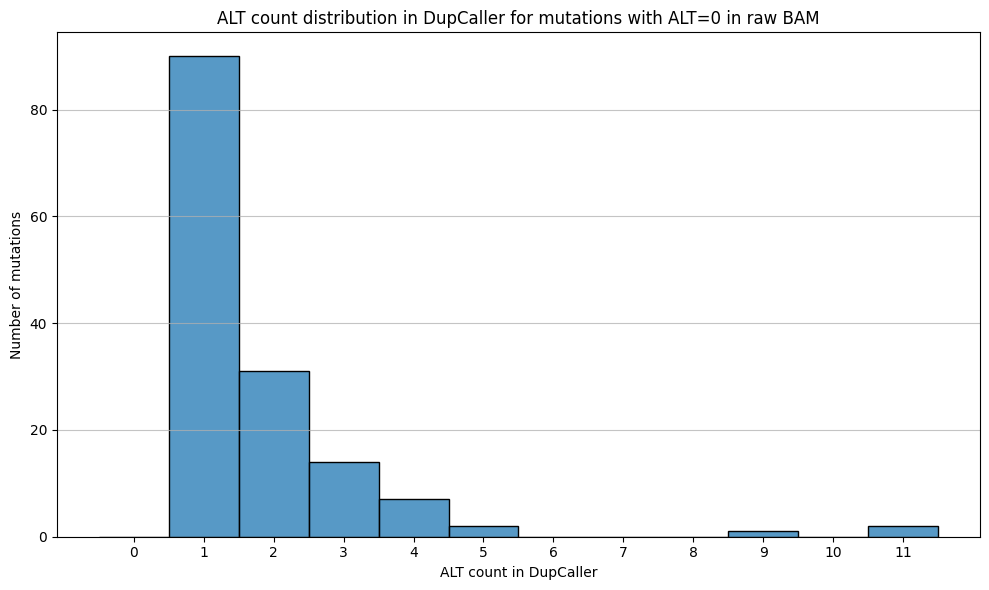

In [18]:
# Filter the dataframe
diff_df = merged_df[merged_df["alt_count_dupcaller"] > 0]

# Barplot showing ALT count distribution in DupCaller for mutations with ALT=0 in raw
plt.figure(figsize=(10, 6))
sns.histplot(diff_df["alt_count_dupcaller"], bins=np.arange(-0.5, diff_df["alt_count_dupcaller"].max() + 1.5, 1), kde=False)
plt.title("ALT count distribution in DupCaller for mutations with ALT=0 in raw BAM")
plt.xlabel("ALT count in DupCaller")
plt.ylabel("Number of mutations")
plt.xticks(np.arange(0, diff_df["alt_count_dupcaller"].max() + 1, 1))
plt.grid(axis="y", alpha=0.75)
plt.tight_layout()
plt.show()


## 3. Visualisation — where are mutations lost?

- **Left:** stacked bar chart per sample showing how many mutations are lost at each stage.
- **Right:** pie chart aggregated across all samples.

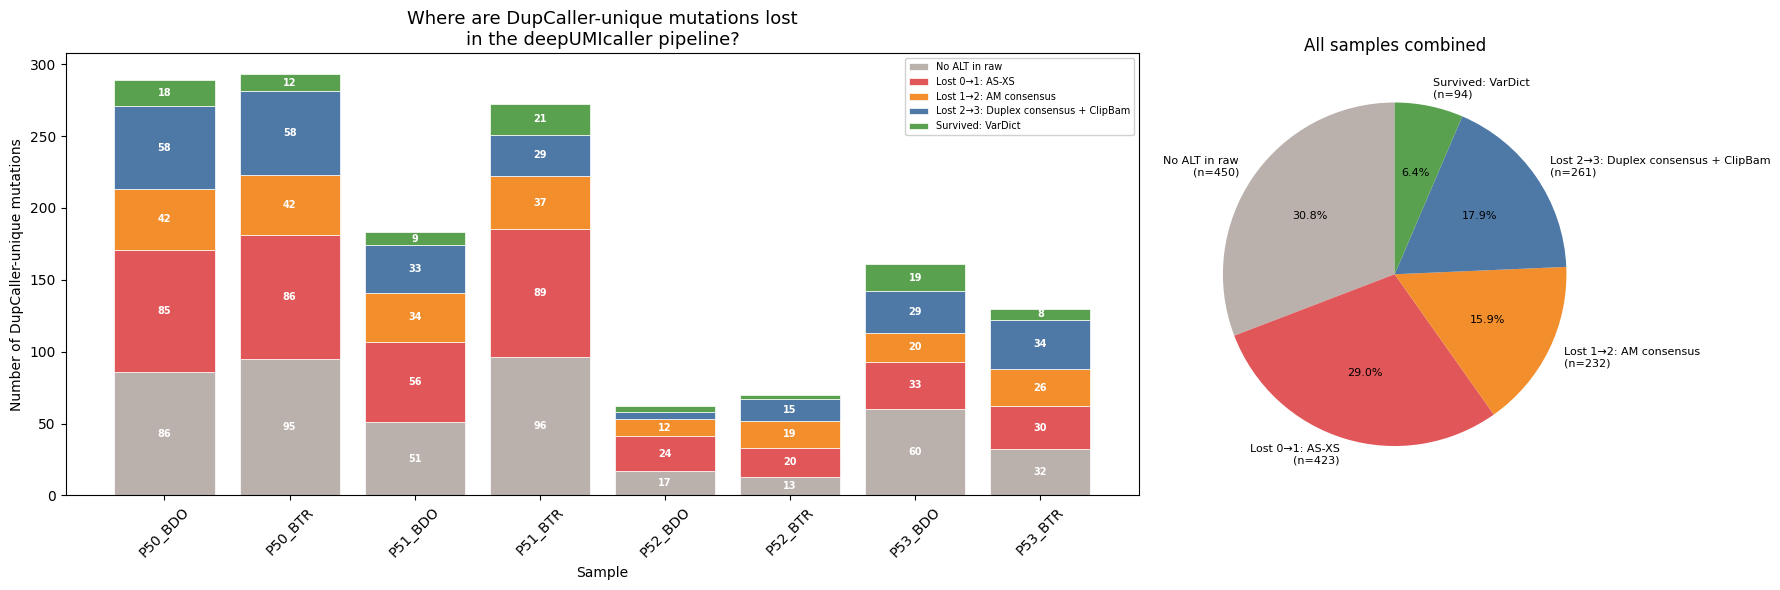

In [9]:
# ── Stacked bar plot per sample + pie chart (aggregated) ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [2.5, 1]})

# ── Left: stacked bar chart per sample ────────────────────────────────────────
ax = axes[0]
short_samples = [s.replace("P19_00", "P").replace("_01", "") for s in pivot.index]
bottom = np.zeros(len(pivot))

for cat in CATEGORIES:
    vals = pivot[cat].values.astype(float)
    bars = ax.bar(short_samples, vals, bottom=bottom,
                  label=cat, color=COLORS[cat], edgecolor="white", linewidth=0.5)
    # Label bars that are large enough
    for bar, val in zip(bars, vals):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(int(val)), ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold")
    bottom += vals

ax.set_ylabel("Number of DupCaller-unique mutations")
ax.set_xlabel("Sample")
ax.set_title("Where are DupCaller-unique mutations lost\nin the deepUMIcaller pipeline?", fontsize=13)
ax.legend(fontsize=7, loc="upper right", framealpha=0.9)
ax.tick_params(axis="x", rotation=45)

# ── Right: pie chart (all samples combined) ───────────────────────────────────
ax = axes[1]
agg_counts = [(tracking_df["loss_category"] == cat).sum() for cat in CATEGORIES]
nonzero = [(cat, cnt) for cat, cnt in zip(CATEGORIES, agg_counts) if cnt > 0]

if nonzero:
    labels_nz = [f"{cat}\n(n={cnt})" for cat, cnt in nonzero]
    counts_nz = [cnt for _, cnt in nonzero]
    colors_nz = [COLORS[cat] for cat, _ in nonzero]
    ax.pie(counts_nz, labels=labels_nz, colors=colors_nz,
           autopct="%1.1f%%", startangle=90, textprops={"fontsize": 8})

ax.set_title("All samples combined", fontsize=12)

fig.tight_layout()
fig.savefig(OUTPUT_BASE / "stage_loss_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. ALT count waterfall across pipeline stages

### 7a. Aggregate waterfall
Show the **mean ALT count** and **mean total depth** across all mutations at each
pipeline stage, grouped by loss category. This reveals the overall pattern of how
signal degrades through the pipeline.

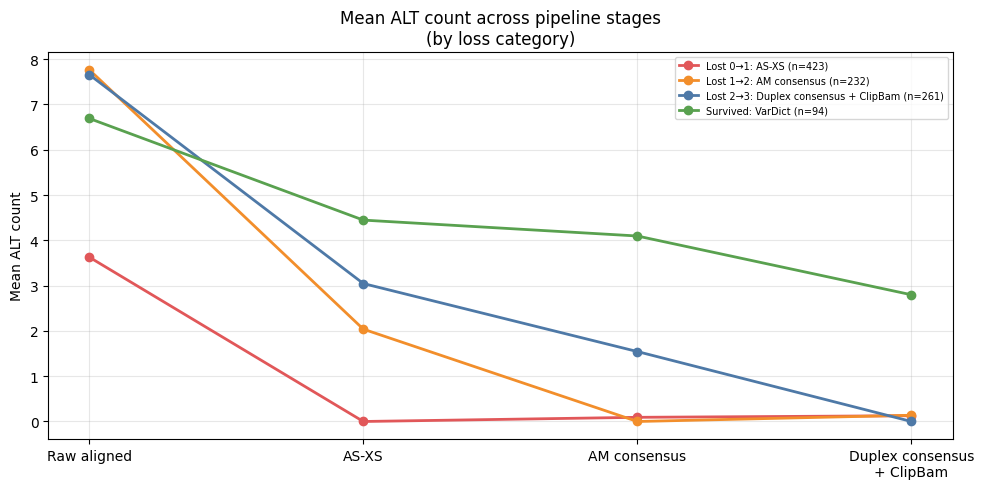

In [10]:
# ── 7b. Aggregate waterfall: mean ALT count per stage ────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

for cat in CATEGORIES:
    if cat == "No ALT in raw":
        continue
    subset = tracking_df[tracking_df["loss_category"] == cat]
    if len(subset) == 0:
        continue
    means = [subset[f"alt_s{i}"].mean() for i in range(len(STAGES))]
    ax.plot(range(len(STAGES)), means, "o-",
            label=f"{cat} (n={len(subset)})",
            color=COLORS.get(cat, "gray"), linewidth=2, markersize=6)

ax.set_xticks(range(len(STAGES)))
ax.set_xticklabels([s["short"] for s in STAGES])
ax.set_ylabel("Mean ALT count")
ax.set_title("Mean ALT count across pipeline stages\n(by loss category)")
ax.legend(fontsize=7, loc="best")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUT_BASE / "aggregate_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Reads supporting suvivied mutations
VarDict is not calling some of the variants for which there are some reads. The mean number of reads is 4 but, I want to know how the distribution.

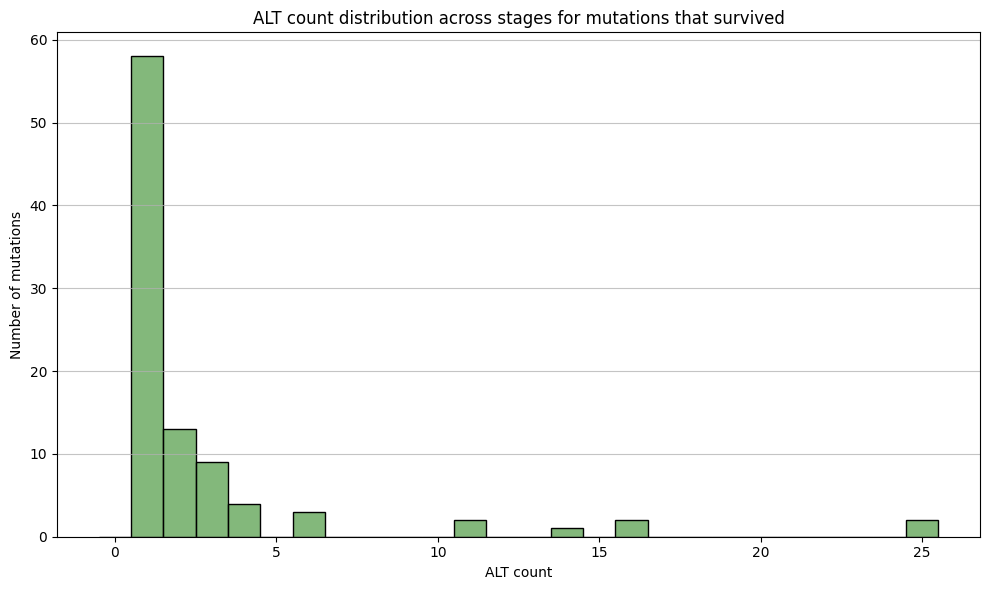

In [23]:
# For the mutations that survived, plot the distribution of ALT counts in the final stage
survived_df = tracking_df[tracking_df["loss_category"] == "Survived: VarDict"]
plt.figure(figsize=(10, 6))
sns.histplot(survived_df["alt_s3"], bins=np.arange(-0.5, survived_df["alt_s3"].max() + 1.5, 1), kde=False, color=COLORS["Survived: VarDict"])
plt.title("ALT count distribution across stages for mutations that survived")
plt.xlabel("ALT count")
plt.ylabel("Number of mutations")
plt.grid(axis="y", alpha=0.75)
plt.tight_layout()
plt.show()

## 9. Summary

In [11]:
# ── Final summary ─────────────────────────────────────────────────────────────

print("═" * 80)
print("FINAL SUMMARY")
print("═" * 80)

total = len(tracking_df)
for cat in CATEGORIES:
    n = (tracking_df["loss_category"] == cat).sum()
    if n > 0:
        print(f"  {cat:<45} {n:>5} ({n/total*100:>5.1f}%)")

print(f"  {'─'*45} {'─'*5}  {'─'*6}")
print(f"  {'TOTAL':<45} {total:>5}")

# Interpretation hints
print("\n" + "─" * 80)
print("Interpretation guide:")
print("  • 'Lost 0→1: AS-XS' = consensus voting collapsed ALT and/or AS-XS removed reads.")
print("  • 'Lost 1→2: AM consensus' = FilterConsensusReadsAM quality filter (--min-reads 2 1 0, --min-base-quality 20).")
print("    → No ClipBam on this path in the pipeline version used.")
print("  • 'Lost 2→3: Duplex consensus + ClipBam' = passes AM consensus filter but fails MED duplex filter (--min-reads 4 2 2,")
print("    both strands, --min-base-quality 30) and/or ClipBam hard-clipping.")
print("    → Stages 2 & 3 are parallel branches from Stage 1, not sequential.")
print("  • 'Survived: VarDict' = ALT is in the duplex BAM but VarDict or post-filters didn't call it.")
print("    → These need further investigation (VarDict thresholds, strand bias, etc.).")

# Save tracking table
tracking_df.to_csv(OUTPUT_BASE / "mutation_tracking.tsv", sep="\t", index=False)

print(f"\n💾 Tracking table saved to: {OUTPUT_BASE / 'mutation_tracking.tsv'}")
print(f"💾 Plots saved to: {OUTPUT_BASE}/")


════════════════════════════════════════════════════════════════════════════════
FINAL SUMMARY
════════════════════════════════════════════════════════════════════════════════
  No ALT in raw                                   450 ( 30.8%)
  Lost 0→1: AS-XS                                 423 ( 29.0%)
  Lost 1→2: AM consensus                          232 ( 15.9%)
  Lost 2→3: Duplex consensus + ClipBam            261 ( 17.9%)
  Survived: VarDict                                94 (  6.4%)
  ───────────────────────────────────────────── ─────  ──────
  TOTAL                                          1460

────────────────────────────────────────────────────────────────────────────────
Interpretation guide:
  • 'Lost 0→1: AS-XS' = consensus voting collapsed ALT and/or AS-XS removed reads.
  • 'Lost 1→2: AM consensus' = FilterConsensusReadsAM quality filter (--min-reads 2 1 0, --min-base-quality 20).
    → No ClipBam on this path in the pipeline version used.
  • 'Lost 2→3: Duplex consensus +